# Denoising Diffusion Probabilistic Models (DDPMs)

In this tutorial, we will create and train an **unconditional** [Denoising Diffusion Probabilistic Model (DDPM)](https://arxiv.org/abs/2006.11239) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/)  functionlalities, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API. It contains implementation of popular diffusion models. All experiments in this tutorial were run on a consumer laptop with an Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM). The code is designed to be lightweight so it can run on modest hardware, at the cost of longer training times and lower image resolution compared to large-scale DDPM setups. On GPUs with more memory, you can increase image resolution, model size, and batch size for better sample quality and faster convergence.

<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ddpm.png" alt="UnCLIP overview" width="1200"/>
  <br>
  <em>An overview of the DDPM pipeline (Ho, J., Jain, A., & Abbeel, P. (2020))</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a DDPM Model](#training-a-ddpm-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

For this tutorial, we will use the [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) dataset from [Torchvision](https://pytorch.org/vision/stable/). This dataset consists of low-resolution black-and-white images, making it suitable for this tutorial.

In [47]:
# Import all necessary libraries and modules for training a DDPM model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.io import read_image
from torchvision.transforms import Resize, CenterCrop
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import glob
# Import required classes from the DDPM module of TorchDiff
import torchdiff
from torchdiff.ddpm import ForwardDDPM, ReverseDDPM, SchedulerDDPM, TrainDDPM, SampleDDPM
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import DiffusionNetwork, Metrics, mse_loss

In [48]:
print(torchdiff.__version__) # latest version 27.Jan.2026

2.2.0


## Downloading the FashionMNIST Dataset from Torchvision

In this section, we will download the [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library. This dataset contains low-resolution black-and-white images, ideal for training a DDPM model in this tutorial.

In [4]:
# Define transformations: convert images to tensors and normalize (mean=0.5, std=0.5) for grayscale images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the FashionMNIST training dataset (28x28 grayscale images)
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load the FashionMNIST test dataset (28x28 grayscale images)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [49]:
# create DataLoader for the training 
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [6]:
def imshow(img):
    # Unnormalize the image: from [-1, 1] back to [0, 1]
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

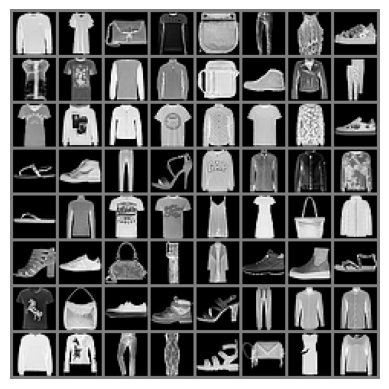

In [7]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

## Training Process for the DDPM Model

Before training a Denoising Diffusion Probabilistic Model (DDPM), we need to prepare several key components required for the training process:

- **DiffusionNetwork ([torchdiff.utils.DiffusionNetwork](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.DiffusionNetwork))**: this is the main network of all fundamental diffusion models (ddpm, ddim and sde) available in TorchDiff library, which is used as noise/score/v/x0 predictor.
 
- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  to train this model we will use adamw oprimizer from pytorch API.

- **Loss Function ([torchdiff.utils.mse_loss](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.mse_loss))**: a simple mean squared error loss implementation which is available in TorchDiff's utils module.

In [8]:
# Initialize the main model (which will be trained to predict noise in this case)
diff_net = DiffusionNetwork(
    in_channels = 1,  # single channel for grayscale images in the training data
    down_channels = [32, 64, 128],
    mid_channels = [128, 128], 
    up_channels = [128, 64, 32],
    down_sampling = [True, True],
    time_embed_dim = 128,
    y_embed_dim = 128,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = False, # continuous time is used for SDE based model time sampling here no need to it
    use_flash_attention = True # if true automatically uses flash attention if available 
)

optim = torch.optim.AdamW(
    [p for p in diff_net.parameters()], lr=1e-4
)

In [9]:
print(sum(p.numel() for p in diff_net.parameters()))

2116993


### Required TorchDiff DDPM Classes for Training and Sampling

To train and sample from the DDPM model, we need the following specific classes from the TorchDiff DDPM module:

- **DDPM Scheduler ([SchedulerDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.SchedulerDDPM))**:
  This class manages the noise schedule for the DDPM model.


- **Forward Diffusion ([ForwardDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.ForwardDDPM))**: forward diffusion class of ddpm model applies forward ddpm process and is used during training. 
  

- **Reverse Diffusion ([ReverseDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.ReverseDDPM))**:
  reverse diffusion class is used during sampling process of ddpm to perform reverse diffusion.

  
- **DDPM Trainer ([TrainDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.TrainDDPM))**:
  This class handles the training of the prepared DDPM model. you can use your own trainer with your specific preferences, but you can also use this trainer and avoid any mistakes and train your model with one line code!


- **DDPM Sampler ([SampleDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.SampleDDPM))**:
  This class handles sampling process. it uses trained model and generates samples.

In [1]:
# here we use a cosine scheduler 
vs = SchedulerDDPM(schedule_type = "cosine")

# forward and reverse diffusion processes, here we should specify prediction type (default: v prediction)
fwd = ForwardDDPM(vs, pred_type = 'noise')
rwd = ReverseDDPM(vs, pred_type = 'noise')

checkpoint = torch.load('best_model_epoch_21.pth', map_location='cpu')

# I stoped training and now it will be start again from the last checkpoint
diff_net.load_state_dict(checkpoint['model_state_dict_diff_net'])
optim.load_state_dict(checkpoint['optim_state_dict'])
fwd.vs.load_state_dict(checkpoint['scheduler_model'])

# DDPM trainer for model training
trainer = TrainDDPM(
    diff_net = diff_net,
    fwd_ddpm = fwd,
    rwd_ddpm = rwd,
    train_loader = train_loader,
    optim = optim,
    loss_fn = mse_loss,
    val_loader = None, # for training efficiency no need to validate during training
    max_epochs = 30, # train for 30 after checkpoint 
    device = 'cuda',
    warmup_steps = 0, # set to zero after checkpointing
    grad_acc = 2, # gradient accumulation (two steps)
    log_freq = 10
)

NameError: name 'SchedulerDDPM' is not defined

In [14]:
# start trining
losses = trainer()

Epoch 1/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [02:03<00:00,  7.58it/s, Loss=0.0635]



Model saved at epoch 1


Epoch 2/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [02:15<00:00,  6.93it/s, Loss=0.0760]



Model saved at epoch 2


Epoch 3/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [02:19<00:00,  6.73it/s, Loss=0.1028]


...

Epoch 28/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [05:20<00:00,  2.92it/s, Loss=0.0808]


Epoch 29/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [05:58<00:00,  2.62it/s, Loss=0.0556]



Model saved at epoch 29


Epoch 30/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [06:08<00:00,  2.54it/s, Loss=0.0748]



Epoch: 30/30 | LR: 1.00e-04 | Train Loss: 0.0724

Model saved at epoch 30
Model saved at epoch 30


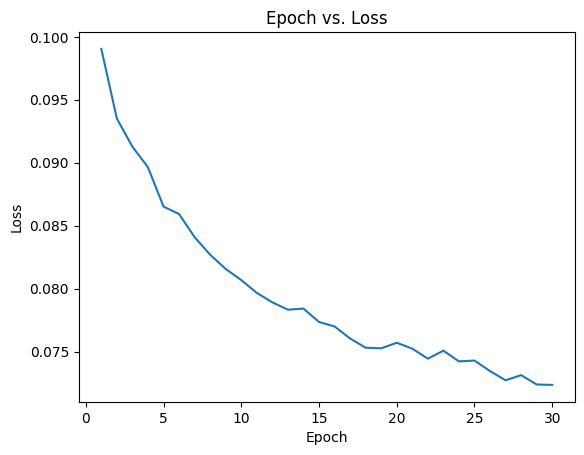

In [53]:
checkpoint_ = torch.load('best_model_epoch_30.pth', map_location='cpu')
losses = checkpoint_['losses']['train_losses']
# unfortunately the losses of the first 21 epochs is not availabe because its file is overwritten by new checkpoints during training
plt.plot([i for i in range(1, 31)], losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling Process for the DDPM Model

After training is finished here we will generate multiple new images and see how well the trained model performs.

In [54]:
# initialize a new DiffusionNetwork with the same architecture as the trained model
diff_net_ = DiffusionNetwork(
    in_channels = 1,
    down_channels = [32, 64, 128],
    mid_channels = [128, 128], 
    up_channels = [128, 64, 32],
    down_sampling = [True, True],
    time_embed_dim = 128,
    y_embed_dim = 128,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = False,
    use_flash_attention = True
)

vs_ = SchedulerDDPM(schedule_type = "cosine")
rwd_ = ReverseDDPM(vs, pred_type = 'noise')


# load the trained parameters into the new DiffusionNetwork and set to evaluation mode
diff_net_.load_state_dict(checkpoint_['model_state_dict_diff_net'])
diff_net_.eval()

rwd.vs.load_state_dict(checkpoint_['scheduler_model'])

<All keys matched successfully>

In [56]:
# sampling process
sampler = SampleDDPM(
    rwd_ddpm=rwd_,
    diff_net=diff_net_,
    img_size=(28, 28),
    batch_size=100, # generates 100 images
    in_channels=1,
    device="cuda",
    norm_range=(-1, 1)
)

In [57]:
gen_imgs = sampler(save_path = 'samples')

Sampling: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:57<00:00, 17.37it/s]


### Visualizing Generated Images

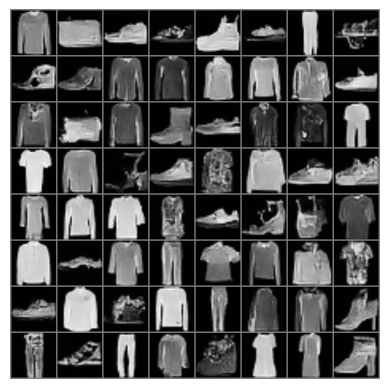

In [58]:

def imshow(img):
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

samples_dir = 'ddpm_samples'
image_paths = sorted(glob.glob(os.path.join(samples_dir, '*')))[:64]
imgs = [read_image(p) for p in image_paths]

resize = Resize(64)
crop = CenterCrop(64)
imgs = [crop(resize(img)) for img in imgs]

batch = torch.stack(imgs, dim=0).float()

batch = batch / 255.0      
batch = batch * 2 - 1          

grid = torchvision.utils.make_grid(batch, nrow=8)
imshow(grid)

### Evaluating the Generated Images

As you can see, the process was successful. Training a diffusion model may not seem like a big deal on high-end hardware, but achieving this with limited computing resources is still a valuable result. You can download the trained model parameters and generated images here: [ddpm](https://github.com/LoqmanSamani/TorchDiff/tree/systembiology/examples/ddpm)

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239)
- [TorchDiff: A PyTorch Library for Denoising Diffusion Probabilistic Models and Beyond](https://medium.com/@samaniloqman91/torchdiff-a-pytorch-library-for-denoising-diffusion-probabilistic-models-and-beyond-d15156e9e3b5)